In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [24]:
from sklearn.datasets import load_iris
iris=load_iris()

In [25]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [26]:
#independent features
X=pd.DataFrame(iris['data'],columns=['sepal length','sepal width','petal length','petal width'])
X

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [27]:
#dependent feature
y=iris['target']
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [29]:
#apply model
from sklearn.tree import DecisionTreeClassifier
decisiontree=DecisionTreeClassifier()
clf=decisiontree.fit(X_train,y_train)

In [30]:
y_pred=decisiontree.predict(X_test)

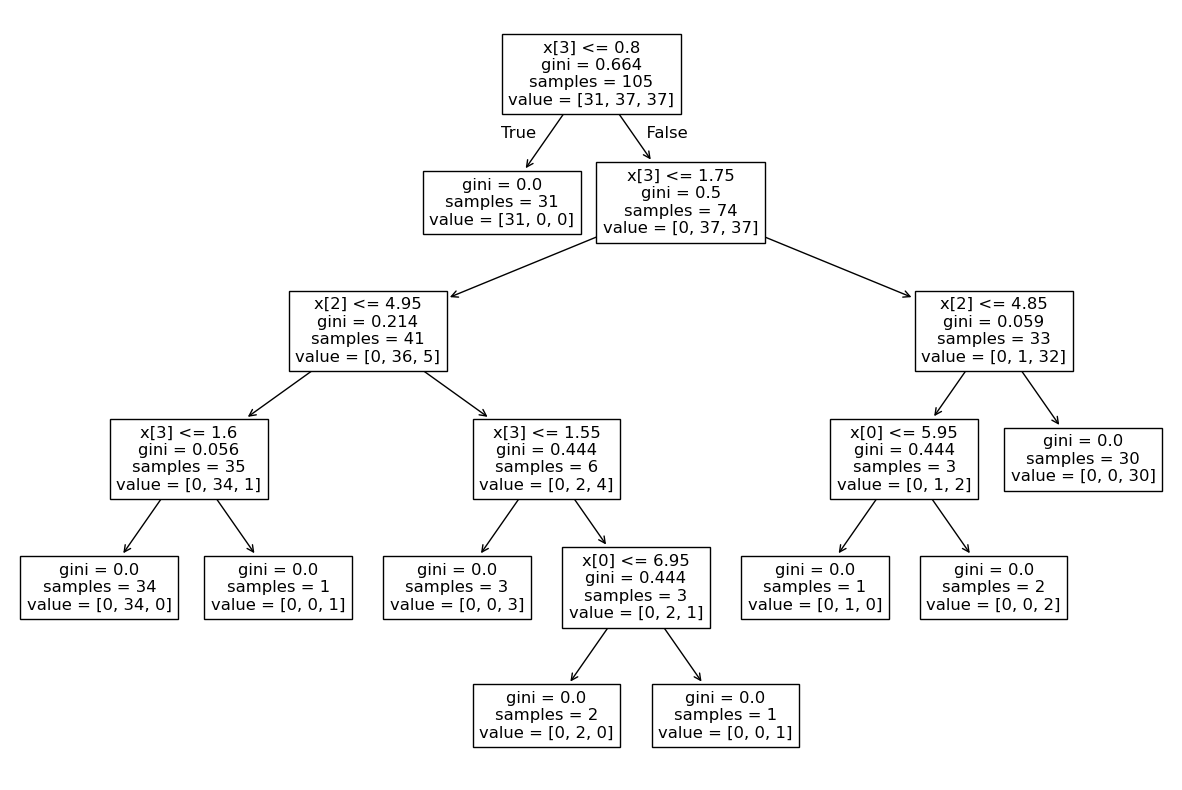

In [31]:
#visualize tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(clf)
plt.show()

In [35]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_pred,y_test)
cr=classification_report(y_pred,y_test)
print(cm)
print(cr)

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Post Prunning

In [32]:
#apply model on same data
from sklearn.tree import DecisionTreeClassifier
clf_post=DecisionTreeClassifier(max_depth=2)
clf_post=clf_post.fit(X_train,y_train)
y_pred_post=clf.predict(X_test)

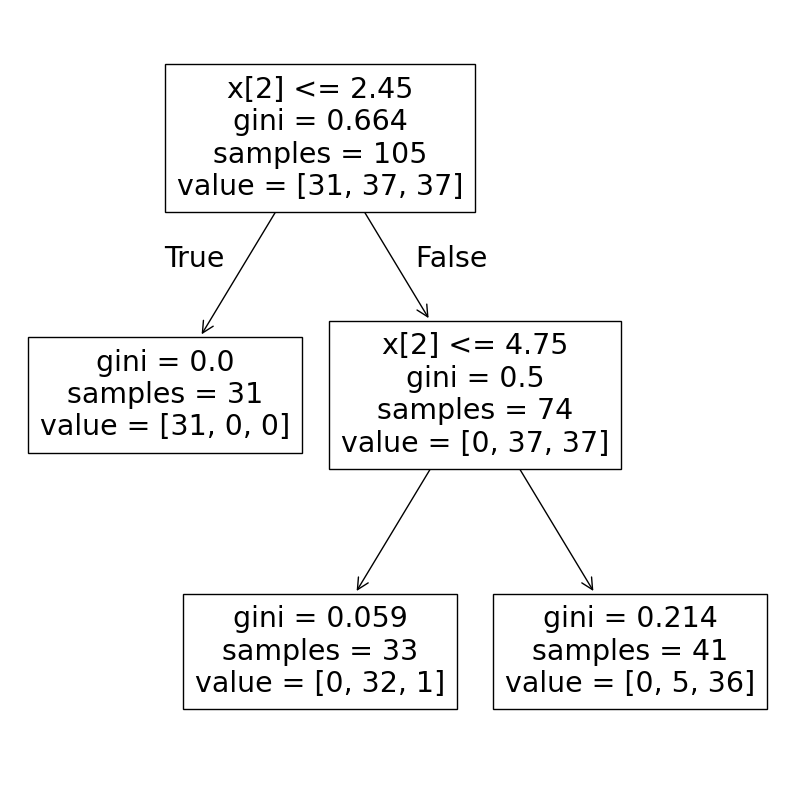

In [34]:
#visualize tree
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(clf_post)
plt.show()

In [38]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_pred_post,y_test)
cr=classification_report(y_pred_post,y_test)
print(cm)
print(cr)

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Pre-Prunning

In [51]:
params={
    'max_depth':[1,2,3,4,5],
    'splitter':['best','random'],
    'max_features':['sqrt','log',None]
}

In [52]:
params

{'max_depth': [1, 2, 3, 4, 5],
 'splitter': ['best', 'random'],
 'max_features': ['sqrt', 'log', None]}

In [53]:
treemodel=DecisionTreeClassifier()
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(treemodel,params,scoring='accuracy',cv=5)
grid.fit(X_train,y_train)
y_pred=grid.predict(X_test)


d:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~~~

In [54]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_pred,y_test)
cr=classification_report(y_pred,y_test)
print(cm)
print(cr)

[[19  0  0]
 [ 0 13  1]
 [ 0  0 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.93      0.96        14
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



In [55]:
grid.best_params_

{'max_depth': 5, 'max_features': None, 'splitter': 'random'}

In [56]:
grid.scoring

'accuracy'

In [57]:
grid.score

<bound method BaseSearchCV.score of GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['sqrt', 'log', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')>